In [52]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
import numpy.random as rng


n_gauss = 4

# ── Build a valid random Gaussian mixture ──────────────────────────────────
weights = rng.random(n_gauss)
weights /= weights.sum()
means = rng.uniform(-4.0, 4.0, size=n_gauss)
sigmas = rng.uniform(0.35, 1.2, size=n_gauss)

def normal_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ── Evaluate the mixture PDF on a grid ─────────────────────────────────────
x_min = np.min(means - 4.0 * sigmas)
x_max = np.max(means + 4.0 * sigmas)
x_grid = np.linspace(x_min, x_max, 1200)
pdf_mix = np.zeros_like(x_grid)
for k in range(n_gauss):
    pdf_mix += weights[k] * normal_pdf(x_grid, means[k], sigmas[k])






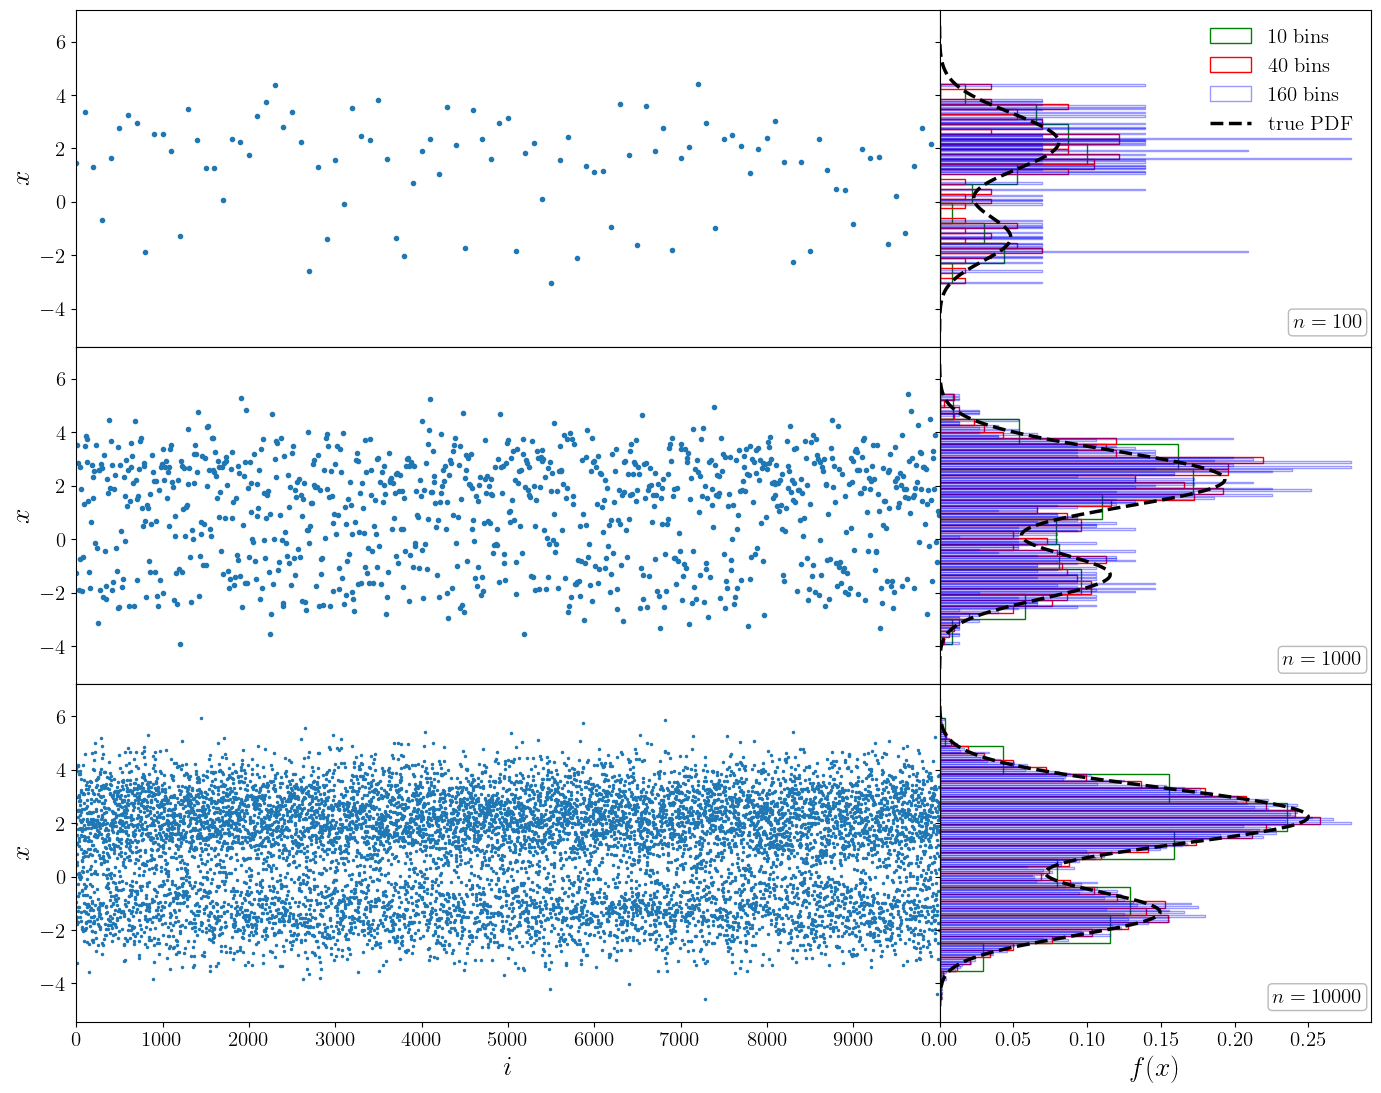

In [53]:
from matplotlib.ticker import MaxNLocator

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

N_values = [100, 1000, 10000]
fig, axs = plt.subplots(
    3, 2, figsize=(14, 11),
    sharey=True,
    gridspec_kw={'wspace': 0.0, 'hspace': 0.0, 'width_ratios': [2, 1]},
)

for row, N_row in enumerate(N_values):
    component_ids = rng.choice(n_gauss, size=N_row, p=weights)
    samples_row = rng.normal(loc=means[component_ids], scale=sigmas[component_ids])

    ax_samp = axs[row, 0]
    ax_hist = axs[row, 1]

    # Left panel: sample points
    marker_size = 3 if N_row <= 1000 else 1.5
    ax_samp.plot(
        np.arange(N_row), samples_row, ls='', marker='o', markersize=marker_size,
        color='tab:blue', label=rf'${N_row}\;\mathrm{{samples}}$'
    )
    ax_samp.set_xlim(0, N_row)
    ax_samp.set_ylabel(r"$x$", fontsize=fontsi2)

    ax_samp.xaxis.set_major_locator(MaxNLocator(prune='upper'))
    ax_samp.tick_params(labelsize=fontsi)
    #ax_samp.legend(fontsize=fontsi, frameon=False, loc='upper right')

    # Right panel: rotated histograms + true PDF
    ax_hist.hist(samples_row, bins=10,  density=True, orientation='horizontal', facecolor='none', edgecolor='green', label=r'$\mathrm{10\;bins}$')
    ax_hist.hist(samples_row, bins=40,  density=True, orientation='horizontal', facecolor='none', edgecolor='red',   label=r'$\mathrm{40\;bins}$')
    ax_hist.hist(samples_row, bins=160, density=True, orientation='horizontal', facecolor='none', edgecolor='blue',  label=r'$\mathrm{160\;bins}$', alpha=0.4)
    ax_hist.plot(pdf_mix, x_grid, color='black', lw=2.5, ls='--', label=r'$\mathrm{true\;PDF}$')
    ax_hist.tick_params(labelsize=fontsi, labelleft=False)

    ax_hist.text(
        0.98, 0.1, rf'$n={N_row}$',
        transform=ax_hist.transAxes, ha='right', va='top', fontsize=fontsi,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.9),
    )

    # Only bottom row shows x-axis labels/ticks
    if row < len(N_values) - 1:
        ax_samp.tick_params(labelbottom=False)
        ax_hist.tick_params(labelbottom=False)
    else:
        ax_samp.set_xlabel(r'$i$', fontsize=fontsi2)
        ax_hist.set_xlabel(r'$f(x)$', fontsize=fontsi2)

# One shared y-label on the middle-left panel
axs[1, 0].set_ylabel(r'$x$', fontsize=fontsi2)

# Show histogram legend only once to avoid repetition
axs[0, 1].legend(fontsize=fontsi, frameon=False, loc='upper right')

fig.subplots_adjust(left=0.06, right=0.985, bottom=0.07, top=0.99, wspace=0.0, hspace=0.0)
plt.savefig('3_plots_samples_hist_stacked.pdf')

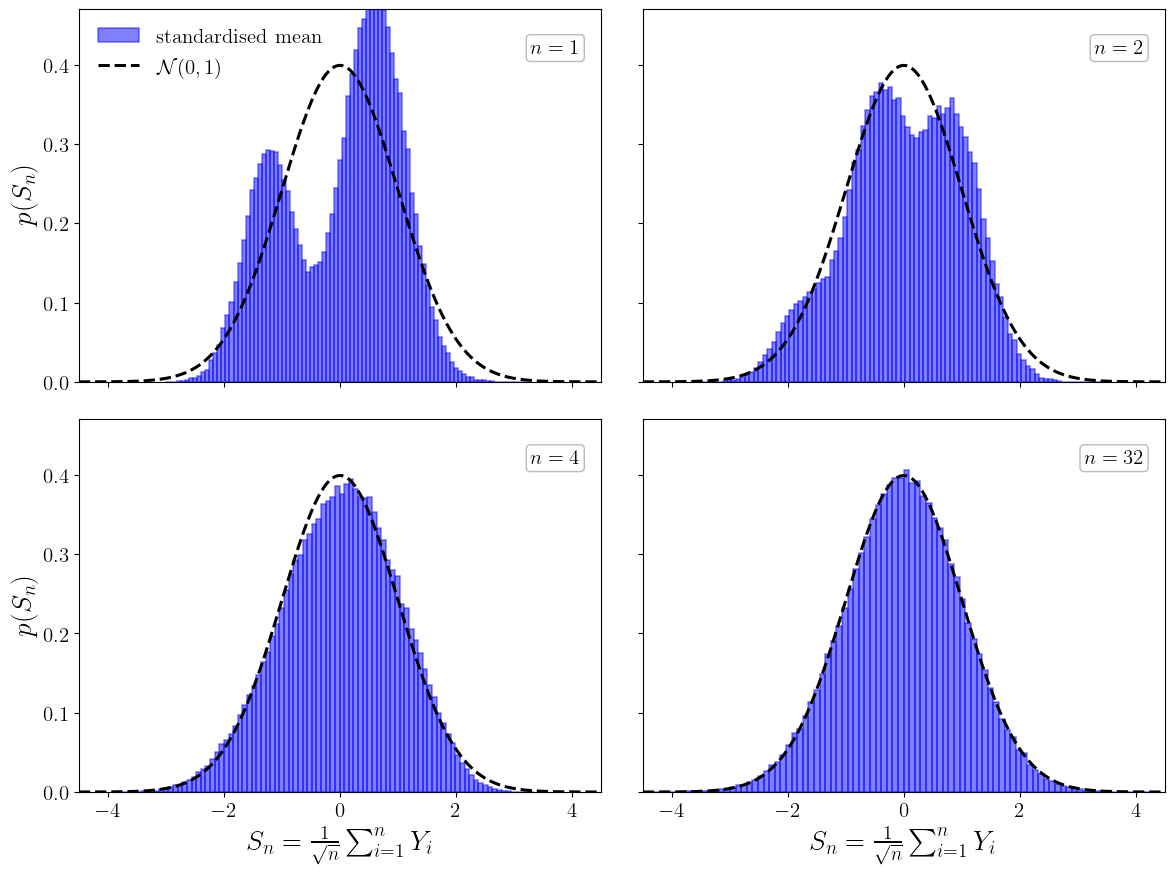

In [54]:

# Parent distribution moments (mixture mean and variance)
mu_parent = np.sum(weights * means)
var_parent = np.sum(weights * (sigmas**2 + means**2)) - mu_parent**2
sigma_parent = np.sqrt(var_parent)

# Draw many i.i.d. samples from the same mixture
n_trials = 120000
max_n = 32
component_ids = rng.choice(n_gauss, size=(n_trials, max_n), p=weights)
all_samples = rng.normal(loc=means[component_ids], scale=sigmas[component_ids])

N_values_clt = [1, 2, 4, 32]
z_grid = np.linspace(-4.5, 4.5, 600)
standard_normal = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z_grid**2)

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axs = axs.ravel()

for ax, N in zip(axs, N_values_clt):
    sample_means = np.mean(all_samples[:, :N], axis=1)
    SN = np.sqrt(N) * (sample_means - mu_parent) / sigma_parent

    ax.hist(
        SN,
        bins=90,
        density=True,
        facecolor='blue',
        edgecolor='blue',
        linewidth=1.1,
        alpha = .5,
        label=rf'$\mathrm{{standardised\ mean}}$'
    )
    ax.plot(z_grid, standard_normal, 'k--', lw=2.2, label=r'$\mathcal{N}(0,1)$')

    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(0.0, 0.47)
    ax.tick_params(labelsize=fontsi)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.text(
        0.96, 0.92, rf'$n={N}$',
        transform=ax.transAxes,
        ha='right', va='top', fontsize=fontsi,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.9),
    )

# Shared labels
axs[2].set_xlabel(r'$S_n = \frac{1}{\sqrt{n}}\sum_{i=1}^n Y_i$', fontsize=fontsi2)
axs[3].set_xlabel(r'$S_n = \frac{1}{\sqrt{n}}\sum_{i=1}^n Y_i$', fontsize=fontsi2)
axs[0].set_ylabel(r'$p(S_n)$', fontsize=fontsi2)
axs[2].set_ylabel(r'$p(S_n)$', fontsize=fontsi2)

# Show legend once
axs[0].legend(fontsize=fontsi, frameon=False, loc='upper left')

fig.subplots_adjust(left=0.08, right=0.985, bottom=0.09, top=0.96, wspace=0.08, hspace=0.1)
plt.savefig('3_plots_clt_convergence.pdf')
plt.show()